=== Schur-Cohn Stability Test (Problem 090302) ===

Initial polynomial:


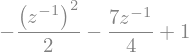


Step 2:


|ζ_2| < 1  →  continue
A*_2(z):


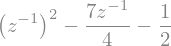

A_1(z):


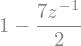


Step 1:


|ζ_1| ≥ 1  →  stop

Reflection coefficients:



Conclusion:
The Schur-Cohn criterion failed.
The system is NOT simultaneously causal and stable.


In [1]:
import sympy as sp
from IPython.display import display

sp.init_printing(use_unicode=True)

z_inv = sp.Symbol('z^{-1}')

print("=== Schur-Cohn Stability Test (Problem 090302) ===")


# ==============================================================================
# INITIAL POLYNOMIAL
# ==============================================================================

A = 1 - sp.Rational(7, 4)*z_inv - sp.Rational(1, 2)*z_inv**2
m = sp.degree(A, z_inv)

print("\nInitial polynomial:")
display(A)


# ==============================================================================
# SCHUR-COHN ALGORITHM
# ==============================================================================

reflection_coefficients = []
stable = True

while m >= 1:

    coeffs = [sp.expand(A).coeff(z_inv, k) for k in range(m + 1)]
    zeta = sp.simplify(coeffs[m])
    reflection_coefficients.append((m, zeta))

    print(f"\nStep {m}:")
    display(sp.Eq(sp.Symbol(f'ζ_{m}'), zeta))
    display(sp.Eq(sp.Symbol(f'|ζ_{m}|'), sp.Abs(zeta)))

    if sp.simplify(zeta**2 < 1):
        print(f"|ζ_{m}| < 1  →  continue")
    else:
        print(f"|ζ_{m}| ≥ 1  →  stop")
        stable = False
        break

    A_star = sp.expand(
        sum(coeffs[m-k] * z_inv**k for k in range(m + 1))
    )

    print(f"A*_{m}(z):")
    display(A_star)

    A = sp.cancel(
        (A - zeta*A_star) / (1 - zeta**2)
    )

    A = sp.expand(A)

    print(f"A_{m-1}(z):")
    display(A)

    m -= 1


# ==============================================================================
# FINAL RESULT
# ==============================================================================

print("\n" + "="*60)

print("Reflection coefficients:")

for order, value in reflection_coefficients:
    display(sp.Eq(sp.Symbol(f'ζ_{order}'), value))

print("\nConclusion:")

if stable:
    print("All reflection coefficients satisfy |ζ_k| < 1.")
    print("The system is causal and stable.")
else:
    print("The Schur-Cohn criterion failed.")
    print("The system is NOT simultaneously causal and stable.")

print("="*60)